# Event rates and cross sections

This notebook uses a counting toy model:

$$N = \Phi\,\sigma\,N_{\rm target}\,T\,\epsilon.$$

It is not a detector simulation. There is no energy spectrum, angular acceptance, background model, reconstruction response, or uncertainty propagation.

In [1]:
from pathlib import Path
import sys

project_root = Path.cwd()
if not (project_root / "src").exists():
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "src"))

import matplotlib.pyplot as plt
import numpy as np

from particle_intro.event_rates import expected_events
from particle_intro.plotting import plot_event_rate_scaling

A single number for the expected count is useful for dimensional thinking. The price is that all spectral information has been integrated out.

In [2]:
N = expected_events(
    flux=1e10,
    cross_section=1e-44,
    n_targets=1e33,
    exposure_time=3.15e7,
    efficiency=0.8,
)
N

2520000.0

Changing the cross section by orders of magnitude changes the expected count by the same orders of magnitude in this toy model.

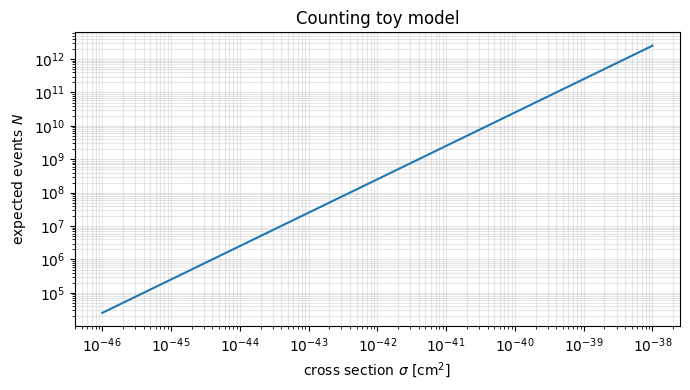

In [3]:
cross_sections = np.logspace(-46, -38, 200)

fig, ax = plt.subplots(figsize=(7, 4))
plot_event_rate_scaling(
    ax,
    cross_sections=cross_sections,
    flux=1e10,
    n_targets=1e33,
    exposure_time=3.15e7,
    efficiency=0.8,
)
ax.set_title("Counting toy model")
fig.tight_layout()

The detector problem starts when the scalar count is replaced by a spectrum:

$$\frac{dN}{dE_{\rm rec}} = T\int dE_\nu\,\Phi(E_\nu)\sigma(E_\nu)R(E_{\rm rec},E_\nu)\epsilon(E_{\rm rec}).$$